<a href="https://colab.research.google.com/github/aluhanska/Data_Analyst-HW/blob/main/HW%2016.2%20%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F%20%D0%BA%D1%80%D0%B5%D0%B4%D0%B8%D1%82%D0%BD%D0%BE%D0%B3%D0%BE%20%D1%80%D0%B8%D0%B7%D0%B8%D0%BA%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score,
)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [3]:
# 1
df = pd.read_csv(
    '/content/drive/MyDrive/Data Analytics/Аналітик даних в IT/credit_risk_dataset.csv',
    sep=None,
    engine='python'
)

In [4]:
# 2
print(f'Розмір датасету: {df.shape}')
print(f'Кількість позичальників: {df.shape[0]:,}')
print(f'Кількість ознак: {df.shape[1]}')

Розмір датасету: (32581, 12)
Кількість позичальників: 32,581
Кількість ознак: 12


In [5]:
# 3
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
# 4
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
# 5
loan_status_percent = df['loan_status'].value_counts(normalize=True).round(4) * 100
loan_status_percent

,proportion
loan_status,
0,78.18
1,21.82


**Висновок:** Маємо справу з задачею незбалансованої класифікації (78 % vs 22 %).


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [8]:
# 1
missing_data = df.isna().mean().round(4) * 100
missing_data

,0
person_age,0.00
person_income,0.00
person_home_ownership,0.00
person_emp_length,2.75
loan_intent,0.00
loan_grade,0.00
loan_amnt,0.00
loan_int_rate,9.56
loan_status,0.00
loan_percent_income,0.00


In [9]:
# 1 - Обчислення медіани для числових колонок з пропущеними значеннями
median_person_emp_length = df['person_emp_length'].median()
median_loan_int_rate = df['loan_int_rate'].median()

# 1 - Створення копії датафрейму
df_updated = df.copy()

# 1 - Заповнення пропусків та збереження змін у таблиці
df_updated.fillna({
    'person_emp_length': median_person_emp_length,
    'loan_int_rate': median_loan_int_rate
}, inplace=True)

# 1 - Перевірка
df_updated.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [10]:
# 2
df_updated.select_dtypes('number').describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.77,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.09,6322.09,3.08,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,8.49,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.11,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


**Висновок:**
* `person_age`: основна маса значень знаходиться у діапазоні від 23 до 30 з медіаною 26. Максимум 144 неможливий: ймовірно значення > 100 - викиди, які треба обробити.
* `person_income`: значення мають гігантську варіантивність - стандартне відхилення (61983) майже = середньому (66075) при медіані 55000. Максимум 6000000 при 79200 - екстримальний викид, який потребує подальшої уваги. Маємо справу з сильним правостороннім перекосом.
* `person_emp_length`: основна маса значень знаходиться у діапазоні від 0 до 7 з медіаною 4. Максимум 123 також неможливий (людина не може працювати більше, ніж жити): такі значення - викиди, які треба обробити.
* `loan_amnt`, `loan_percent_income`, `cb_person_cred_hist_length`: всі розподіли мають помірний правосторонній перекос.
* `loan_int_rate`: нормальний розподіл (середнє значення 11.01 ≈ медіана 10.99).

In [11]:
# 3 - Знаходимо межі викидів (IQR)

Q1 = df_updated['person_income'].quantile(0.25)
Q3 = df_updated['person_income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(-22550.0), np.float64(140250.0))

In [12]:
# 3 - Знаходимо кількість викидів
outliers = df_updated[
    (df_updated['person_income'] < lower_bound)
    | (df_updated['person_income'] > upper_bound)
]
len(outliers)

1484

In [13]:
# 3 - Видаляємо викиди
df_clean = df_updated[
    (df_updated['person_income'] >= lower_bound)
    & (df_updated['person_income'] <= upper_bound)
].copy()

In [14]:
# 3 - Перевіряємо результат
print(f'Було позичальників: {df_updated.shape[0]:,}')
print(f'Стало позичальників: {df_clean.shape[0]:,}')

Було позичальників: 32,581
Стало позичальників: 31,097


In [15]:
# 3 - Перевіряємо базову статистику
df_clean.select_dtypes('number').describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31097.0,31097.00,31097.00,31097.00,31097.00,31097.00,31097.00,31097.00
mean,27.6,58705.00,4.69,9289.72,11.00,0.22,0.17,5.73
std,6.2,27519.06,3.96,6038.67,3.08,0.42,0.11,4.01
min,20.0,4000.00,0.00,500.00,5.42,0.00,0.01,2.00
25%,23.0,38000.00,2.00,5000.00,8.49,0.00,0.09,3.00
50%,26.0,54000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.0,75000.00,7.00,12000.00,13.11,0.00,0.23,8.00
max,123.0,140004.00,123.00,35000.00,23.22,1.00,0.83,30.00


Приймаємо рішення дообробити викиди для числових колонок `person_age` та `person_emp_length`, з огляду на те, що максимальне значення (123) залишається досить високим, що є фізично неможливим.

In [16]:
# Залишаємо лише реалістичні значення для віку позичальника та його стажу роботи.
# Стаж роботи не може бути більшим за вік позичальника
# (приймаємо 16, так як з даного віку дозволено офіційно працювати)

df_final = df_clean[
    (df_clean['person_age'] <= 100) &
    (df_clean['person_emp_length'] <= 60) &
    (df_clean['person_emp_length'] <= df_clean['person_age'] - 16)
].copy()

In [17]:
# Знову перевіряємо результат
print(f'Було позичальників: {df_clean.shape[0]:,}')
print(f'Стало позичальників: {df_final.shape[0]:,}')

Було позичальників: 31,097
Стало позичальників: 30,395


In [18]:
# Та перевіряємо базову статистику
df_final.select_dtypes('number').describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,30395.00,30395.00,30395.00,30395.00,30395.00,30395.00,30395.00,30395.00
mean,27.66,58646.66,4.57,9269.36,11.00,0.22,0.17,5.76
std,6.18,27540.05,3.84,6037.64,3.08,0.42,0.11,4.03
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.01,2.00
25%,23.00,37835.00,2.00,5000.00,8.49,0.00,0.09,3.00
50%,26.00,54000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,75000.00,7.00,12000.00,13.11,0.00,0.23,8.00
max,94.00,140004.00,41.00,35000.00,23.22,1.00,0.83,30.00


In [19]:
# 4 - Статус кредиту за типом володіння житлом

pho_loan_status = (
    df_final
    .groupby(['person_home_ownership', 'loan_status'])
    .size()
    .unstack()
)
pho_loan_status_pct = (
    pho_loan_status
    .div(pho_loan_status.sum(axis=1), axis=0)
    .round(4)
    * 100
)
pho_loan_status_pct

loan_status,0,1
person_home_ownership,,
MORTGAGE,87.13,12.87
OTHER,67.68,32.32
OWN,92.17,7.83
RENT,68.12,31.88


In [20]:
# 4 - Частота зустрічання різних значень за типом володіння житлом
df_final['person_home_ownership'].value_counts(normalize=True).round(4) * 100

,proportion
person_home_ownership,
RENT,52.01
MORTGAGE,39.76
OWN,7.90
OTHER,0.33


**Висновок:** Тип житла - сильний предиктор дефолту. Орендарі (RENT) і OTHER ризикові (~32 % дефолтів), тоді як іпотечники (MORTGAGE) - 12.9 %, власники (OWN) - 7.9 %. За частотою домінують RENT (52.0 %) і MORTGAGE (39.8 %) - ~92 % даних. OTHER лише 0.33 %, тож його ставка дефолту ненадійна. Наявність нерухомості знижує ризик - логічна закономірність.

In [21]:
# 4 - Статус кредиту за метою кредиту

li_loan_status = (
    df_final
    .groupby(['loan_intent', 'loan_status'])
    .size()
    .unstack()
)
li_loan_status_pct = (
    li_loan_status
    .div(li_loan_status.sum(axis=1), axis=0)
    .round(4)
    * 100
)
li_loan_status_pct

loan_status,0,1
loan_intent,,
DEBTCONSOLIDATION,71.09,28.91
EDUCATION,82.38,17.62
HOMEIMPROVEMENT,72.68,27.32
MEDICAL,72.83,27.17
PERSONAL,79.42,20.58
VENTURE,84.44,15.56


In [22]:
# 4 - Частота зустрічання різних значень за метою кредиту
df_final['loan_intent'].value_counts(normalize=True).round(4) * 100

,proportion
loan_intent,
EDUCATION,19.81
MEDICAL,18.84
VENTURE,17.48
PERSONAL,16.96
DEBTCONSOLIDATION,15.93
HOMEIMPROVEMENT,10.97


**Висновок:** Мета кредиту - слабший предиктор, ніж тип житла. Усі категорії в межах ~16–29 % дефолтів. Найризикованіші - DEBTCONSOLIDATION (28.9 %), HOMEIMPROVEMENT (27.3 %), MEDICAL (27.2 %) і PERSONAL (20.6 %); найнадійніші - EDUCATION (17.6 %) і VENTURE (15.6 %). За частотою категорії розподілені досить рівномірно: від EDUCATION (19.9 %) до HOMEIMPROVEMENT (11.0 %), тож усі оцінки статистично надійні.

In [23]:
# 4 - Статус кредиту за кредитним рейтингом

lg_loan_status = (
    df_final
    .groupby(['loan_grade', 'loan_status'])
    .size()
    .unstack()
)
lg_loan_status_pct = (
    lg_loan_status
    .div(lg_loan_status.sum(axis=1), axis=0)
    .round(4)
    * 100
)
lg_loan_status_pct

loan_status,0,1
loan_grade,,
A,89.68,10.32
B,83.11,16.89
C,78.61,21.39
D,39.52,60.48
E,33.79,66.21
F,28.24,71.76
G,1.79,98.21


In [24]:
# 4 - Частота зустрічання різних значень за кредитним рейтингом
df_final['loan_grade'].value_counts(normalize=True).round(4) * 100

,proportion
loan_grade,
A,33.20
B,31.92
C,19.96
D,11.13
E,2.89
F,0.71
G,0.18


**Висновок:** Кредитний рейтинг - найсильніший предиктор дефолту. Спостерігається чітка монотонність: від A (10.3 % дефолтів) до G (98.2 %). Рейтинги A–C відносно надійні (10–22 %), а починаючи з D ризик різко зростає (60+ %), що робить цю змінну дуже інформативною для моделі. За частотою домінують вищі рейтинги: A (33.2 %), B (31.9 %) і C (20.0 %) - разом ~85 % даних. Нижчі рейтинги рідкісні: E (2.9 %), F (0.7 %), G (0.18 %), тож їхні (дуже високі) ставки дефолту статистично менш надійні через малу вибірку.

In [25]:
# 4 - Статус кредиту за історією дефолтів

cbpdof_loan_status = (
    df_final
    .groupby(['cb_person_default_on_file', 'loan_status'])
    .size()
    .unstack()
)
cbpdof_loan_status_pct = (
    cbpdof_loan_status
    .div(cbpdof_loan_status.sum(axis=1), axis=0)
    .round(4)
    * 100
)
cbpdof_loan_status_pct

loan_status,0,1
cb_person_default_on_file,,
N,81.04,18.96
Y,61.41,38.59


In [26]:
# 4 - Частота зустрічання різних значень за історією дефолтів
df_final['cb_person_default_on_file'].value_counts(normalize=True).round(4) * 100

,proportion
cb_person_default_on_file,
N,82.36
Y,17.64


**Висновок:** Наявність дефолту в історії - значущий предиктор. Позичальники з минулим дефолтом (Y) дефолтять помітно частіше - 38.6 % проти 19.0 % у тих, хто без нього (N), тобто вдвічі вищий ризик. Закономірність логічна: минула поведінка передбачає майбутню. За частотою більшість позичальників мають чисту історію - N (82.4 %), Y лише 17.6 %, але вибірка достатня, щоб оцінки були надійними.

In [27]:
# 5 - Статус кредиту vs вік позичальника
fig = px.box(
    df_final,
    x='loan_status',
    y='person_age',
    title='Вік позичальника vs статус кредиту',
    labels={
        'loan_status': 'Статус кредиту',
        'person_age': 'Вік позичальника'
    },
    color='loan_status'
)

fig.show()

**Висновок:** Вік слабо розрізняє платників і дефолтерів. Обидві групи мають практично однакову медіану (26 років) і дуже схожі квартилі (23–30). Розподіли майже повністю накладаються, тож `person_age` - слабкий предиктор дефолту.

In [28]:
# 5 - Статус кредиту vs річний дохід
fig = px.box(
    df_final,
    x='loan_status',
    y='person_income',
    title='Річний дохід vs статус кредиту',
    labels={
        'loan_status': 'Статус кредиту',
        'person_income': 'Річний дохід'
    },
    color='loan_status'
)

fig.show()

**Висновок:** На відміну від віку, дохід помітно розрізняє групи. Платники (0) мають вищий дохід - медіана 58k проти 40k у дефолтерів (1). Уся «коробка» дефолтерів зміщена вниз (квартилі ~30–59k проти ~41–80k у платників). Тобто `person_income` - значущий предиктор: нижчий дохід пов'язаний з вищим ризиком дефолту, що логічно.

In [29]:
# 5 - Статус кредиту vs стаж роботи
fig = px.box(
    df_final,
    x='loan_status',
    y='person_emp_length',
    title='Стаж роботи vs статус кредиту',
    labels={
        'loan_status': 'Статус кредиту',
        'person_emp_length': 'Стаж роботи'
    },
    color='loan_status'
)

fig.show()

**Висновок:** Стаж роботи має слабкий зв'язок зі статусом кредиту. Платники (0) мають трохи більший стаж - медіана 4 роки проти 3 у дефолтерів (1), та їхня «коробка» зміщена ледь вище (квартилі 2–7 проти 1–6). Напрямок логічний - довший стаж означає стабільнішу зайнятість і нижчий ризик, - але різниця невелика, тож `person_emp_length` - слабкий-помірний предиктор, помітно слабший за дохід.

In [30]:
# 5 - Статус кредиту vs сума кредиту
fig = px.box(
    df_final,
    x='loan_status',
    y='loan_amnt',
    title='Сума кредиту vs статус кредиту',
    labels={
        'loan_status': 'Статус кредиту',
        'loan_amnt': 'Сума кредиту'
    },
    color='loan_status'
)

fig.show()

**Висновок:** Сума кредиту помітно пов'язана зі статусом - і в очікуваному напрямку. Дефолтери (1) беруть більші суми: медіана 9.5k проти 7.6k у платників (0), а вся їхня «коробка» зміщена вгору (квартилі 5–15k проти 5–12k). Тобто `loan_amnt` - помірний предиктор: більші кредити частіше йдуть у дефолт.

In [31]:
# 5 - Статус кредиту vs відсоткова ставка
fig = px.box(
    df_final,
    x='loan_status',
    y='loan_int_rate',
    title='Відсоткова ставка vs статус кредиту',
    labels={
        'loan_status': 'Статус кредиту',
        'loan_int_rate': 'Відсоткова ставка'
    },
    color='loan_status'
)

fig.show()

**Висновок:** Відсоткова ставка - один із найсильніших числових предикторів. Дефолтери (1) мають помітно вищу ставку: медіана ~13 % проти ~11 % у платників (0), і вся їхня «коробка» чітко зміщена вгору (квартилі ~11–15 % проти ~8–12 %). Перекриття розподілів менше, ніж у попередніх змінних, тож `loan_int_rate` несе сильний сигнал: вища ставка пов'язана з вищим ризиком дефолту.

In [32]:
# 5 - Статус кредиту vs відношення кредиту до доходу
fig = px.box(
    df_final,
    x='loan_status',
    y='loan_percent_income',
    title='Відношення кредиту до доходу vs статус кредиту',
    labels={
        'loan_status': 'Статус кредиту',
        'loan_percent_income': 'Відношення кредиту до доходу'
    },
    color='loan_status'
)

fig.show()

**Висновок:** Відношення кредиту до доходу чітко розрізняє групи. Дефолтери (1) мають значно вищий показник: медіана ~0.24 проти ~0.14 у платників (0), а вся їхня «коробка» помітно зміщена вгору (квартилі ~0.14–0.34 проти ~0.09–0.20). Тобто `loan_percent_income` - сильний предиктор: чим більшу частку доходу з'їдає кредит, тим вищий ризик дефолту. Логічно - велике боргове навантаження відносно доходу важче обслуговувати.

In [33]:
# 5 - Статус кредиту vs довжина кредитної історії
fig = px.box(
    df_final,
    x='loan_status',
    y='cb_person_cred_hist_length',
    title='Довжина кредитної історії vs статус кредиту',
    labels={
        'loan_status': 'Статус кредиту',
        'cb_person_cred_hist_length': 'Довжина кредитної історії'
    },
    color='loan_status'
)

fig.show()

**Висновок:** довжина кредитної історії практично не розрізняє групи. Обидва розподіли майже ідентичні - однакова медіана (4 роки), однакові квартилі (3–8) і схожі хвости викидів. Тобто `cb_person_cred_hist_length` - слабкий предиктор дефолту, один із найменш інформативних серед числових ознак, разом із віком.


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [34]:
# 1
correlation_matrix = df_final.select_dtypes('number').corr()

fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляційна матриця для числових змінних',
    labels=dict(color='Кореляція')
)

fig.update_layout(height=600)
fig.show()

In [35]:
# 2
selected_cat_cols = [
    'person_home_ownership', 'loan_intent',
    'loan_grade', 'cb_person_default_on_file'
]
df_encoded = pd.get_dummies(df_final, columns=selected_cat_cols, drop_first=True)
df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True
5,21,9900,2.0,2500,7.14,1,0.25,2,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False


Приймаємо рішення виключити числові колонки з r < |0.1| відносно цільової змінної (`loan_status`):
* `person_age` (r = -0.02);
* `cb_person_cred_hist_length` (r = -0.01).

In [36]:
# 3
exclude_cols = ['loan_status', 'person_age', 'cb_person_cred_hist_length']
feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]
feature_cols

['person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'person_home_ownership_OTHER',
 'person_home_ownership_OWN',
 'person_home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'loan_grade_B',
 'loan_grade_C',
 'loan_grade_D',
 'loan_grade_E',
 'loan_grade_F',
 'loan_grade_G',
 'cb_person_default_on_file_Y']


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [37]:
# 1
X = df_encoded[feature_cols]
y = df_encoded['loan_status']

print(f'Кількість ознак: {X.shape[1]}')
print(f'Розмір вибірки: {X.shape[0]:,}')

Кількість ознак: 20
Розмір вибірки: 30,395


In [38]:
X.head()

,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,9600,5.0,1000,11.14,0.10,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,9600,1.0,5500,12.87,0.57,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,65500,4.0,35000,15.23,0.53,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,54400,8.0,35000,14.27,0.55,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True
5,9900,2.0,2500,7.14,0.25,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False


In [39]:
# 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape[0]} клієнтів')
print(f'Test: {X_test.shape[0]} клієнтів')
print(f'Статус кредиту в train: {y_train.mean():.1%}')
print(f'Статус кредиту в test: {y_test.mean():.1%}')

Train: 24316 клієнтів
Test: 6079 клієнтів
Статус кредиту в train: 22.4%
Статус кредиту в test: 22.4%


In [40]:
# 3
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled, X_test_scaled

(array([[-1.387221  , -0.67237563, -1.34030237, ..., -0.0853862 ,
         -0.04257685, -0.46139903],
        [-0.85651294,  1.93757054, -1.20767095, ..., -0.0853862 ,
         -0.04257685, -0.46139903],
        [-0.12966101,  0.63259746,  0.94758955, ..., -0.0853862 ,
         -0.04257685, -0.46139903],
        ...,
        [-0.83833801, -1.19436486, -0.87609241, ..., -0.0853862 ,
         -0.04257685, -0.46139903],
        [ 0.77937645, -1.19436486, -0.54451387, ..., -0.0853862 ,
         -0.04257685, -0.46139903],
        [ 0.59748172, -0.67237563,  2.60548224, ..., -0.0853862 ,
         -0.04257685, -0.46139903]]),
 array([[ 1.02666459, -1.19436486,  0.1186432 , ..., -0.0853862 ,
         -0.04257685, -0.46139903],
        [-0.96556254, -0.67237563,  0.45022174, ..., -0.0853862 ,
         -0.04257685, -0.46139903],
        [ 1.68797772, -0.93337025,  0.94758955, ..., -0.0853862 ,
         -0.04257685,  2.16732141],
        ...,
        [-0.35848342, -0.41138101, -0.21293534, ..., -

In [41]:
# 4
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
model

LogisticRegression(max_iter=1000, random_state=42)

In [42]:
# 5 - Прогнозуємо класи та ймовірності для тренувальної вибірки
y_train_pred = model.predict(X_train_scaled)
y_train_pred_proba = model.predict_proba(X_train_scaled)
y_train_pred, y_train_pred_proba

(array([0, 0, 0, ..., 0, 0, 0]),
 array([[0.89695295, 0.10304705],
        [0.99569453, 0.00430547],
        [0.80513692, 0.19486308],
        ...,
        [0.93506494, 0.06493506],
        [0.96476661, 0.03523339],
        [0.96982653, 0.03017347]]))

In [43]:
# 5 - Прогноз на тренувальній вибірці
sample_train_predictions = pd.DataFrame({
    'Реальний дефолт': y_train.values[:5],
    'Прогноз': y_train_pred[:5],
    'Ймовірність оплати': y_train_pred_proba[:5, 0].round(3),
    'Ймовірність дефолту': y_train_pred_proba[:5, 1].round(3)
})
sample_train_predictions.head()

,Реальний дефолт,Прогноз,Ймовірність оплати,Ймовірність дефолту
0,0,0,0.897,0.103
1,0,0,0.996,0.004
2,0,0,0.805,0.195
3,0,0,0.960,0.040
4,1,1,0.239,0.761


In [44]:
# 5 - Прогнозуємо класи та ймовірності для тестової вибірки
y_test_pred = model.predict(X_test_scaled)
y_test_pred_proba = model.predict_proba(X_test_scaled)
y_test_pred, y_test_pred_proba

(array([0, 0, 0, ..., 0, 0, 0]),
 array([[0.98613572, 0.01386428],
        [0.71909109, 0.28090891],
        [0.96998148, 0.03001852],
        ...,
        [0.79652185, 0.20347815],
        [0.91612935, 0.08387065],
        [0.86594077, 0.13405923]]))

In [45]:
# 5 - Прогноз на тестовій вибірці
sample_test_predictions = pd.DataFrame({
    'Реальний дефолт': y_test.values[:5],
    'Прогноз': y_test_pred[:5],
    'Ймовірність оплати': y_test_pred_proba[:5, 0].round(3),
    'Ймовірність дефолту': y_test_pred_proba[:5, 1].round(3)
})
sample_test_predictions.head()

,Реальний дефолт,Прогноз,Ймовірність оплати,Ймовірність дефолту
0,0,0,0.986,0.014
1,0,0,0.719,0.281
2,0,0,0.970,0.030
3,0,0,0.945,0.055
4,0,0,0.734,0.266



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


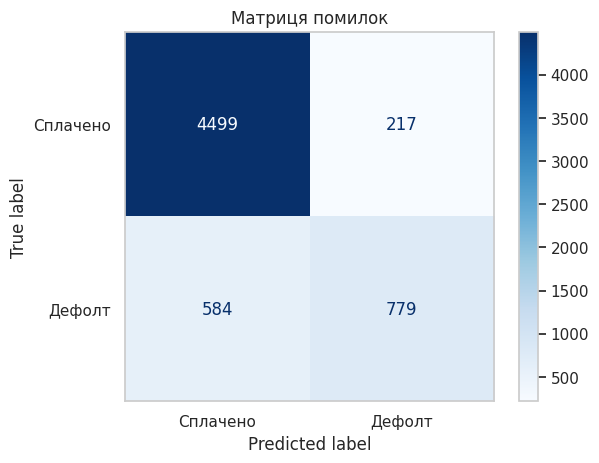

In [46]:
# 1
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Сплачено', 'Дефолт']
)
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.grid(False)
plt.show()

In [47]:
# 2
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print('МЕТРИКИ ЯКОСТІ МОДЕЛІ:')
print(f'Accuracy (Точність):   {accuracy:.3f}')
print(f'Precision (Влучність): {precision:.3f}')
print(f'Recall (Повнота):      {recall:.3f}')
print(f'F1-score:              {f1:.3f}')

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):   0.868
Precision (Влучність): 0.782
Recall (Повнота):      0.572
F1-score:              0.660


In [48]:
# 3
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_test_pred_proba[:, 1])

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=fpr, y=tpr,
    mode='lines',
    name=f'ROC (AUC = {auc:.3f})'
))
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(dash='dash'),
    name='Випадковий класифікатор'
))

fig.update_layout(
    title='ROC-крива',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate'
)

fig.show()

In [49]:
# 4
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False).round(3)

feature_importance

,feature,coefficient,abs_coefficient
4,loan_percent_income,1.302,1.302
15,loan_grade_D,0.803,0.803
2,loan_amnt,-0.520,0.520
16,loan_grade_E,0.469,0.469
6,person_home_ownership_OWN,-0.459,0.459
7,person_home_ownership_RENT,0.402,0.402
12,loan_intent_VENTURE,-0.381,0.381
8,loan_intent_EDUCATION,-0.330,0.330
18,loan_grade_G,0.273,0.273
17,loan_grade_F,0.258,0.258


**5. Висновок:** у нас модель хорошої якості (AUC = 0.876). 3 ознаки, які найбільше впливають на прогноз:
* `loan_percent_income` (|coefficient| = 1.302);
* `loan_grade_D	` (|coefficient| = 0.803);
* `loan_amnt` (|coefficient| = 0.502).


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [50]:
# 1
thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_test_pred_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'Precision': precision_score(y_test, y_pred_custom),
        'Recall': recall_score(y_test, y_pred_custom),
        'F1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах класифікації',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг'}
)

fig.show()

2. Отже, оптимальний поріг для бізнес-задачі, виходячи з попереднього пункту, - 0.35.

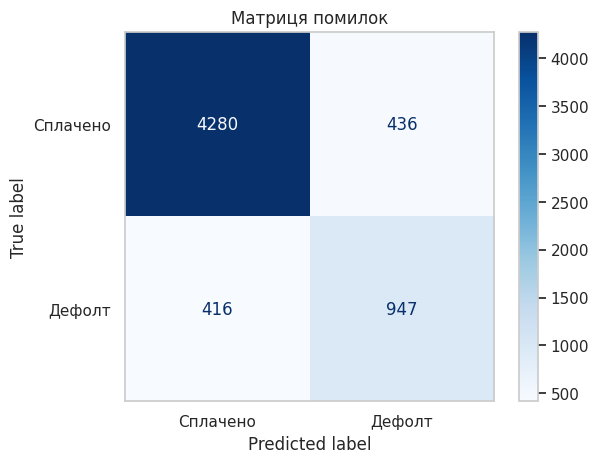

In [51]:
y_pred_opt = (y_test_pred_proba[:, 1] >= 0.35).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Сплачено', 'Дефолт']
)
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.grid(False)
plt.show()


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [52]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).round(3)
results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.868,0.782,0.572,0.660,0.876
1,Decision Tree,0.906,0.923,0.635,0.753,0.881
2,Random Forest,0.932,0.960,0.726,0.827,0.936


**Висновок:** *RandomForestClassifier* дає найкращий результат на тестовому наборі.